# Characterising Systematic Biases in Context-Specific Protein Interaction Networks Inferred from Single-Cell Transcriptomes

In this report, we utilise scNET (https://doi.org/10.1038/s41592-025-02627-0) as a model integrative method to establish an analytical framework for characterising systematic biases in single-cell data reconstruction and cell-type-specific PPI inference. Specifically, we aim to determine whether these biases reflect genuine biological signals or are simply methodological artefacts.

To determine whether integrating scRNA-seq and PPI information produces network-informed representations that accurately reflect biologically meaningful cellular organisation, we propose an analytical pipeline consisting of four analyses:

1. UMAP clustering
   * To assess the reservation of biologically coherent cell clusters
2. Differential gene expression (DGE) analysis
   * To examine the fidelity of cluster-specific transcriptional signatures
3. Pathway enrichment
   * To examine the fidelity of cluster-specific transcriptional signatures on a modular level
4. Rank-weight analysis:
   * To determine whether scNET expression redistribution can be explained by local neighborhood structure 

## Imports and function definitions

In [148]:
import os
import re

import numpy as np
import pandas as pd
import seaborn as sns
import venn
import matplotlib.pyplot as plt
import seaborn as sns
from venn import venn

import networkx as nx
import anndata as ad 
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr

import gseapy as gp
from gseapy import barplot, dotplot

### Functions: DGE analysis

In [4]:
def load_and_preprocess_data(h5ad_path):
    """
    Load and preprocess AnnData object prior to run_scNET (run once on raw). 
    
    Args:
        h5ad_path: Path to h5ad file
        subsample_n: Maximum number of cells  
    
    Returns:
        Preprocessed AnnData object
    """
    print(f"Loading data from: {h5ad_path}")
    adata = ad.read_h5ad(h5ad_path)
    print(f"Initial shape: {adata.shape}")
    
    # Ensure raw counts are in .X
    if 'counts' in adata.layers:
        print("Moving counts from layers to .X")
        adata.X = adata.layers['counts'].copy()
    
    # Store raw counts
    adata.raw = adata.copy()
    
    # Basic filtering
    print("Filtering cells and genes...")
    sc.pp.filter_cells(adata, min_genes=10)
    sc.pp.filter_genes(adata, min_cells=10)
    
    print("Cleaning data (removing NaN/Inf)...")
    if sp.issparse(adata.X):
        bad = ~np.isfinite(adata.X.data)
        if bad.any():
            print(f"Found {bad.sum()} non-finite values, setting to 0")
            adata.X.data[bad] = 0.0
    else:
        np.nan_to_num(adata.X, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Remove zero-variance genes
    print("Removing zero-variance genes...")
    if sp.issparse(adata.X):
        gene_var = np.array((adata.X.power(2).mean(0) - np.square(adata.X.mean(0))).A1)
    else:
        gene_var = adata.X.var(axis=0)
    
    keep = np.isfinite(gene_var) & (gene_var > 0)
    n_removed = (~keep).sum()
    if n_removed > 0:
        print(f"Removing {n_removed} zero-variance genes")
        adata = adata[:, keep].copy()
    
    # Handle column name conflicts
    conflicts = adata.obs.columns.intersection(pd.Index(adata.var_names))
    if len(conflicts) > 0:
        print(f"Renaming {len(conflicts)} conflicting obs columns")
        adata.obs.rename(columns={c: f"{c}_obs" for c in conflicts}, inplace=True)
    
    # Store cleaned raw data
    adata.raw = adata.copy()
    
    print(f"Final shape: {adata.shape}")

    return adata

In [93]:
def get_cluster_deg_set(
    adata,
    groupby,
    output_prefix=None,
    top_k=None,
    lfc_threshold=1.5, 
    pval_threshold=0.05, 
    method="wilcoxon"
):
    """
    Loop DGE analysis across AnnData objects.

    Args:
       adata: AnnData object 
       groupby: Cluster grouping label
       output_prefix: Write to disk when specified
       top_k: Specify to cut off at top k DEGs 
       lfc_threshold: Cut off for DEGs by log2FC (default: 1.5)
       pval_threshold: Cut off for DEGs by p-values (default: 0.05)
       method: Statistical method used in DGE analysis (default: wilcoxon)
    
    """
    
    # Safety check
    if top_k is not None and (lfc_threshold is not None or pval_threshold is not None):
        raise ValueError("Use either 'top_k' or  'lfc_threshold + pval_threshold', not both.")
        
    # Run DE across clusters
    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby,
        method=method,
        use_raw=False
    )
    
    all_degs = set()
    cluster_deg_sets = {}
    cluster_counts = {}
    
    # Loop over clusters
    for clust in sorted(adata.obs[groupby].unique()):

        df = sc.get.rank_genes_groups_df(adata, group=clust)
        df = df[["names", "logfoldchanges", "pvals_adj"]]
        
        # --- OPTION 1: top K ---
        if top_k is not None:
            df_sig = df.nsmallest(top_k, "pvals_adj").copy()

        # --- OPTION 2: thresholds ---
        else:
            if lfc_threshold is None or pval_threshold is None:
                raise ValueError("lfc_threshold and pval_threshold must be provided if top_k is None.")
                
            df_sig = df[
                (df["logfoldchanges"] >= lfc_threshold) &
                (df["pvals_adj"] < pval_threshold)
            ].copy()

        genes = set(df_sig["names"])
        
        # store 
        cluster_deg_sets[clust] = genes
        cluster_counts[clust] = len(df_sig)
        all_degs.update(genes)

        # Add cluster label 
        df_sig["cluster"] = clust
   
        # Write to disk when output_prefix is specified
        if output_prefix is not None:
            df_sig.to_csv(f"./DE_results/{output_prefix}_cluster_{clust}.csv", index=False)

    # Free Scanpy memory
    del adata.uns["rank_genes_groups"]

    return all_degs, cluster_deg_sets, cluster_counts

### Functions: UMAP clustering

In [19]:
def process_with_embeddings(
    adata,
    embeddings_path,
    cluster_col=None,
    embedding_key='X_scNET_embedding',
    n_neighbors=15,
    metric='euclidean',
    leiden_resolution=1.0,
    compute_leiden=True,
    save_path=None,
    umap_save=None,
    random_state=42
):
    """
    Load embeddings, compute UMAP, and calculate silhouette scores.
    
    Args:
        adata: AnnData or str
            AnnData object or path to h5ad file
        embeddings_path: str
            Path to parquet file with embeddings
        cluster_col: str, optional
            Column in adata.obs to use for silhouette calculation
            If None and compute_leiden=True, uses 'leiden'
        embedding_key: str
            Key to store embeddings in adata.obsm (default: 'X_embedding')
        n_neighbors: int
            Number of neighbors for UMAP (default: 15)
        metric: str
            Distance metric: 'euclidean' or 'cosine' (default: 'euclidean')
        leiden_resolution: float
            Resolution for Leiden clustering (default: 1.0)
        compute_leiden: bool
            Whether to compute Leiden clustering (default: True)
        save_path: str, optional
            Path to save processed h5ad file
        random_state: int
            Random seed (default: 42)
        
    Returns:
        dict:
            Results with adata, silhouette scores, and summary statistics
    """
    
    # Load adata
    if isinstance(adata, str):
        print(f"Loading AnnData from: {adata}")
        adata = sc.read_h5ad(adata)
    else:
        adata = adata.copy()
    
    print(f"Initial shape: {adata.shape}")
    
    # Load embeddings 
    print(f"\nLoading embeddings from: {embeddings_path}")
    embeddings_df = pd.read_parquet(embeddings_path)
    print(f"Embeddings shape: {embeddings_df.shape}")
    print(f"AnnData cells: {adata.n_obs}")
    
    # ========================================
    # Handling duplicates if exist
    # ========================================
    
    # Check for duplicates in AnnData
    if not adata.obs_names.is_unique:
        print("\nWARNING: Duplicate cell names in AnnData")
        n_dup_adata = adata.obs_names.duplicated().sum()
        print(f"  Found {n_dup_adata} duplicate names")
        
        # Check for duplicates in embeddings
        if not embeddings_df.index.is_unique:
            print("  Embeddings also have duplicates")
            n_dup_emb = embeddings_df.index.duplicated().sum()
            print(f"  Found {n_dup_emb} duplicate indices")
            
            # Make BOTH unique in the SAME WAY
            print("  Making both unique in sync...")
            
            # Option 1: Make AnnData unique, then align embeddings to match
            # Store original order
            original_names = adata.obs_names.copy()
            
            # Make AnnData names unique
            adata.obs_names_make_unique()
            
            # Now make embeddings index match
            # For each duplicate in original, assign the same suffix
            from collections import defaultdict
            name_counts = defaultdict(int)
            new_embedding_index = []
            
            for name in original_names:
                if name_counts[name] == 0:
                    new_embedding_index.append(name)
                else:
                    new_embedding_index.append(f"{name}-{name_counts[name]}")
                name_counts[name] += 1
            
            embeddings_df.index = new_embedding_index
            
            print(f" * Both now have {adata.n_obs} unique names")
        else:
            print("  Embeddings are unique, making AnnData unique...")
            adata.obs_names_make_unique()
            print(" * Fixed")
    
    elif not embeddings_df.index.is_unique:
        print("WARNING: Duplicate indices in embeddings only")
        embeddings_df = embeddings_df[~embeddings_df.index.duplicated(keep='first')]
        print(" * Kept first occurrence")
    
    # Now they should match perfectly
    print(f"\nChecking alignment...")
    print(f"  AnnData cells: {adata.n_obs}")
    print(f"  Embeddings cells: {len(embeddings_df)}")
    print(f"  AnnData unique: {adata.obs_names.is_unique}")
    print(f"  Embeddings unique: {embeddings_df.index.is_unique}")
    
    # Verify they match
    if adata.n_obs == len(embeddings_df):
        # Check if order matches
        if (adata.obs_names == embeddings_df.index).all():
            print(" * Perfect match! Cells are in same order")
        else:
            print("  Cell counts match but order differs, aligning...")
            # Reorder embeddings to match adata
            embeddings_df = embeddings_df.loc[adata.obs_names]
            print(" * Aligned")
    else:
        # Find common cells
        common_cells = adata.obs_names.intersection(embeddings_df.index)
        print(f"WARNING: Only {len(common_cells)} cells match")
        
        if len(common_cells) == 0:
            raise ValueError(
                f"No matching cells!\n"
                f"AnnData example: {adata.obs_names[0]}\n"
                f"Embeddings example: {embeddings_df.index[0]}"
            )
        
        # Subset both to common cells
        adata = adata[common_cells, :].copy()
        embeddings_df = embeddings_df.loc[common_cells]
        print(f"  → Using {len(common_cells)} common cells")
    
    # Add embeddings
    adata.obsm[embedding_key] = embeddings_df.values  # Use .values since order now matches
    print(f"\nAdded embeddings to adata.obsm['{embedding_key}']")
    print(f"  Embedding dimensions: {adata.obsm[embedding_key].shape[1]}")
    
    # ========================================
    # 2. Compute neighbors
    # ========================================
    
    print(f"\nComputing neighbors (n_neighbors={n_neighbors}, metric={metric})...")
    sc.pp.neighbors(
        adata,
        use_rep=embedding_key,
        n_neighbors=n_neighbors,
        metric=metric,
        random_state=random_state
    )
    
    # ========================================
    # 3. Compute UMAP
    # ========================================
    
    print("Computing UMAP...")
    sc.tl.umap(adata, random_state=random_state)
    
    # ========================================
    # 4. Clustering
    # ========================================
    
    if compute_leiden:
        print(f"Computing Leiden clustering (resolution={leiden_resolution})...")
        sc.tl.leiden(adata, resolution=leiden_resolution, random_state=random_state)
        
        if cluster_col is None:
            cluster_col = 'scNET_embedding_leiden'
    
    # ========================================
    # 5. Calculate silhouette scores
    # ========================================
    
    results = {
        'adata': adata,
        'n_cells': adata.n_obs,
        'embedding_dims': adata.obsm[embedding_key].shape[1]
    }
    
    if cluster_col is None:
        print("\nNo cluster column specified, skipping silhouette calculation")
        results['silhouette_score'] = None
        
    elif cluster_col not in adata.obs.columns:
        print(f"\nWARNING: Cluster column '{cluster_col}' not found")
        print(f"Available columns: {adata.obs.columns.tolist()}")
        results['silhouette_score'] = None
        
    else:
        valid_mask = ~adata.obs[cluster_col].isna()
        n_clusters = adata.obs[cluster_col][valid_mask].nunique()
        
        print(f"\n{cluster_col}: {n_clusters} clusters, {valid_mask.sum()} cells")
        
        if n_clusters >= 2:
            silhouette = silhouette_score(
                adata.obsm[embedding_key][valid_mask],
                adata.obs[cluster_col][valid_mask]
            )
            print(f"Silhouette score: {silhouette:.3f}")
            
            results['silhouette_score'] = silhouette
            results['n_clusters'] = n_clusters
            results['cluster_col'] = cluster_col
        else:
            print(f"Cannot calculate silhouette: only {n_clusters} cluster(s)")
            results['silhouette_score'] = None
            results['n_clusters'] = n_clusters
    
    # ========================================
    # 6. Visualize
    # ========================================
    
    print("\nGenerating UMAP plots...")
    
    # Plot clusters
    colors_to_plot = []
    
    if compute_leiden:
        colors_to_plot.append('scNET_embedding_leiden')
    if cluster_col and cluster_col != 'scNET_embedding_leiden' and cluster_col in adata.obs.columns:
        colors_to_plot.append(cluster_col)
    
    if colors_to_plot:
        sc.pl.umap(adata, color=colors_to_plot, legend_loc='right margin', show=False)
    else:
        sc.pl.umap(adata, show=False)
        sc.pl.umap(adata)
        
    if umap_save:
        plt.savefig(umap_save, dpi=300, bbox_inches='tight')
        print(f"✓ Saved UMAP to: {umap_save}")
    
    plt.show()
    plt.close()
    
    # ========================================
    # 7. Save
    # ========================================
    
    if save_path:
        adata.write(save_path)
        print(f"\nSaved to: {save_path}")
    
    # Print summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Cells: {results['n_cells']}")
    print(f"Embedding dimensions: {results['embedding_dims']}")
    if results.get('n_clusters'):
        print(f"Clusters: {results['n_clusters']}")
    if results.get('silhouette_score'):
        print(f"Silhouette score: {results['silhouette_score']:.3f}")
    
    return results

### Functions: Pathway enrichment

In [92]:
def run_pathway_enrichment_for_cluster(
    adata,
    cluster_name,
    groupby="rank_genes_groups",
    gene_sets=None,
    lfc_threshold=0,
    pval_threshold=0.05,
    output_dir="./gsea_results"
):
    """
    Perform pathway enrichment (ORA) for one cluster using Enrichr, following scNET-style filtering.

    Args:
        adata: AnnData object 
        cluster_name: Cluster grouping label
        gene_sets: Gene set used for Enrichr overrepresentation analysis (default: KEGG_2021_Human)
        lfc_threshold: Cut off for DEGs by log2FC (default: 0)
        pval_threshold: Cut off for DEGs by p-values (default: 0.05)
    Returns:
    
    """

    print(f"\nProcessing cluster: {cluster_name}")

    # Ensure uppercase genes
    adata.var.index = adata.var.index.str.upper()

    # Get gene sets
    if gene_sets is None:
        gene_sets = gp.get_library("KEGG_2021_Human")

    # Filter gene sets to genes present in dataset
    filtered_gene_sets = {
        pathway: [gene for gene in genes if gene in adata.var.index]
        for pathway, genes in gene_sets.items()
    }

    filtered_gene_sets = {
        pathway: genes for pathway, genes in filtered_gene_sets.items()
        if len(genes) > 0
    }

    # Get DE genes
    de_df = sc.get.rank_genes_groups_df(
        adata,
        group=cluster_name,
        key=groupby
    )

    de_df["names"] = de_df["names"].str.upper()

    # Apply filtering
    filtered_de = de_df[
        (de_df["logfoldchanges"] > lfc_threshold) &
        (de_df["pvals_adj"] < pval_threshold)
    ]

    if filtered_de.empty:
        print("  No significant DE genes found.")
        return None, None

    gene_list = filtered_de["names"].tolist()

    print(f"  {len(gene_list)} significant genes")

    # Run Enrichr
    try:
        enr = gp.enrichr(
            gene_list=gene_list,
            gene_sets=filtered_gene_sets,
            background=list(adata.var.index),
            organism="Human",
            outdir=None
        )
    except Exception as e:
        print(f"  ERROR running enrichment: {e}")
        return None, None

    results = enr.results

    # Filter significant pathways
    significant = results[results["Adjusted P-value"] < 0.05]

    print(f"  Found {len(significant)} significant pathways")

    # Optional: save results
    if output_dir is not None:
        cluster_output_dir = os.path.join(output_dir, cluster_name.replace(" ", "_"))
        os.makedirs(cluster_output_dir, exist_ok=True)
        results.to_csv(os.path.join(cluster_output_dir, "enrichment_results.csv"), index=False)

    return results, significant

In [63]:
def plot_pathway_heatmap(enrichment_results_dict, 
                         pathway_list=None,
                         cluster_order=None,
                         top_n=20,
                         figsize=(12, 20),
                         vmax_cap=100,
                         save_fig=None,
                         bar_pos=[0.65, 0.03, 0.25, 0.025]):
    """
    Plot standardized heatmap of -log10(adjusted p-value) across clusters.
    
    Parameters
    ----------
    enrichment_results_dict : dict
        {cluster_name: enrichment_dataframe}
    top_n : int
        Number of top pathways per cluster
    figsize : tuple
        Figure size
    vmax_cap : float
        Maximum value for color scaling (caps extreme values)
    """

    combined_df = pd.DataFrame()

    # Get top pathways per cluster
    for cluster, df in enrichment_results_dict.items():
    
        if df is None or df.empty:
            continue
    
        if pathway_list is None:
            selected_df = df.sort_values("Adjusted P-value").head(top_n)
        else:
            selected_df = df[df["Term"].isin(pathway_list)]
    
        selected_df = selected_df[["Term", "Adjusted P-value"]].copy()
        selected_df["Cluster"] = cluster
    
        combined_df = pd.concat([combined_df, selected_df])

    # Remove duplicates
    combined_df = combined_df.drop_duplicates()

    # Compute -log10 p-values
    combined_df["-log10(adj_p)"] = -np.log10(
        combined_df["Adjusted P-value"].clip(lower=1e-300)
    )

    # Pivot
    pivot_df = combined_df.pivot(
        index="Term",
        columns="Cluster",
        values="-log10(adj_p)"
    )

    pivot_df = pivot_df.replace([np.inf, -np.inf], np.nan)

    if pathway_list is not None:
        pivot_df = pivot_df.reindex(pathway_list)
    
    pivot_df = pivot_df.fillna(0)

    # Cap extreme values for better visualization
    max_value = pivot_df.max().max()
    print(f"Maximum -log10(adj_p): {max_value}")
    pivot_df = pivot_df.clip(upper=vmax_cap)

    if pivot_df.shape[0] < 2:
        row_cluster = False
    else:
        row_cluster = True

    # Enforce cluster order
    if cluster_order is not None:
        # Only include clusters that exist in the data
        existing_clusters = [c for c in cluster_order if c in pivot_df.columns]
        missing_clusters = [c for c in pivot_df.columns if c not in cluster_order]
        
        if missing_clusters:
            print(f"Warning: Clusters not in custom order: {missing_clusters}")
            existing_clusters.extend(missing_clusters)
        
        # Reorder
        pivot_df = pivot_df[existing_clusters]

    # Plot
    g = sns.clustermap(
        pivot_df,
        cmap="YlGnBu",          # sequential for p-values
        vmin=0,
        vmax=vmax_cap,           # standardized scale
        figsize=figsize,
        row_cluster=False,
        col_cluster=False,
        linewidths=0.5,
        cbar_kws={
            "label": "-log10(adj. p-value)",
            "orientation": "horizontal"
        }
    )

    g.ax_col_dendrogram.set_visible(False)
    
    # Improve label formatting
    g.ax_heatmap.set_yticklabels(
        g.ax_heatmap.get_yticklabels(),
        fontsize=12
    )

    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(),
        rotation=45,
        ha="right"
    )
    
    g.ax_heatmap.set_xlabel("Clusters", fontsize=12)
    g.ax_heatmap.set_ylabel("Pathway", fontsize=12)

    g.cax.set_position(bar_pos) # (left, bottom, width, height)

    if save_fig is not None:
        if isinstance(save_fig, str):
            g.fig.savefig(save_fig, dpi=300, bbox_inches="tight")
        elif save_fig is True:
            g.fig.savefig("pathway_heatmap.png", dpi=300, bbox_inches="tight")

    plt.show()

### Functions: Rank-weight analysis

In [103]:
def mean_log_expr(adata, assume_log=True):
    """
    Compute mean log expression per gene.

    If adata.raw exists:
        log1p(raw)
    Else:
        - assume_log = True → use adata.X as-is
        - assume_log = False → log1p(adata.X)

    Returns pd.Series indexed by gene names
    """

    def to_dense(X):
        return X.toarray() if hasattr(X, "toarray") else X

    # Best case: raw exists
    if adata.raw is not None:
        X = to_dense(adata.raw.X)
        X_log = np.log1p(X)
        genes = adata.raw.var_names
        return pd.Series(X_log.mean(axis=0), index=genes)

    # No raw → be explicit
    X = to_dense(adata.X)

    if assume_log:
        return pd.Series(X.mean(axis=0), index=adata.var_names)
    else:
        X_log = np.log1p(X)
        return pd.Series(X_log.mean(axis=0), index=adata.var_names)

In [133]:
def load_G(G_path):
    """
    Loads a graph .csv file and constructs a NetworkX graph.
    Standardises column names and removes invalid nodes. 
    Returns both the df and the graph (G).
    """

    print("=" * 80)
    print("Loading network...")
    print("=" * 80)
    
    G_path = os.path.expanduser(G_path)
    df_G = pd.read_csv(G_path) # Load file (put in index_col=0 if there is an index column)

    # normalize column names
    df_G.columns = df_G.columns.str.strip().str.lower()

    # Flexible column mapping
    col_mapping = {
        "g1": "Protein_A",
        "gene1": "Protein_A",
        "symbol1": "Protein_A",
        "protein1": "Protein_A",
        "node1": "Protein_A",
        "g1_symbol": "Protein_A",
    
        "g2": "Protein_B",
        "gene2": "Protein_B",
        "symbol2": "Protein_B",
        "protein2": "Protein_B",
        "node2": "Protein_B",
        "g2_symbol": "Protein_B",
    
        "score": "weight",
        "confidence": "weight",
        "weight": "weight",
        "connection": "weight",
        "conn":"weight"
    }
    
    # Rename only matching columns
    df_G.rename(columns={c: col_mapping[c] for c in df_G.columns if c in col_mapping}, inplace=True)
    
    # Clean symbols
    for col in ["Protein_A", "Protein_B"]:
        df_G[col] = (
            df_G[col]
            .astype(str)
            .str.replace("\ufeff", "", regex=False)
            .str.strip()
            .str.upper()
        )
    
    # Ensure numeric edge weight
    if "weight" in df_G.columns:
        df_G["weight"] = pd.to_numeric(df_G["weight"], errors="coerce")
        
    # --- BUILD NETWORKX GRAPH --- # 
    G = nx.from_pandas_edgelist(
        df_G,
        source="Protein_A",
        target="Protein_B",
        edge_attr="weight",
        create_using=nx.Graph()
    )
    
    # Remove invalid nodes
    invalid_nodes = [
        n for n in G.nodes
        if not isinstance(n, str) or n.strip() == "" or n == "-1"
    ]
    
    if invalid_nodes:
        print(f"  - Found {len(invalid_nodes)} invalid nodes, removing examples: {invalid_nodes[:10]}")
        G.remove_nodes_from(invalid_nodes)
    
    print(f"\nNetwork loaded with {G.number_of_nodes():,} nodes and {G.number_of_edges():,} edges.\n")

    return df_G, G



def get_neighbors(G, genes, min_weight=0.5, top_k=None): 
    """
    Extract direct and second-degree neighbors.
    
    For each query gene, find:
     - direct neighbors (distance 1) with weight (w) >= min_weight
     - second-degree neighbors (distance 2, not direct) with weight (w3) = w * w2 (where w2 >= min_weight)
     - if top_k in given:
            * keep all direct neighbors first
            * fill remaining slots with highest-weight second-degree neighbors

    Returns:
        df_neighbors: df with columns query_gene | neighbor | rank (“direct” / “second-degree”) | weight
        df_summary: per-query summary (with direct_neighbor_count, second_neighbor_count, and total_neighbor_count)
        processed_gene_count: number of genes found in the network (int)
    """
    
    rows = []
    summary_rows = []
    missing = []
    no_neighbors = []

    for gene in genes:
        
        if gene not in G:
            missing.append(gene)
            continue

        # DIRECT NEIGHBORS
        direct_list = []
        
        for n in G.neighbors(gene):
            w = G[gene][n].get("weight", 0)
            if w >= min_weight:
                direct_list.append((n, w))

        # sort by weight descending
        direct_list = sorted(direct_list, key=lambda x: x[1], reverse=True)

        # SECOND-DEGREE NEIGHBORS (gene - n - n2)
        second_degree = {}
    
        for n, w in direct_list:          
            for n2, attrs2 in G[n].items():               
                w2 = attrs2.get("weight", 0)
    
                if (
                    w2 >= min_weight
                    and n2 != gene
                    and n2 not in dict(direct_list)        
                ):

                    w3 = w * w2 # w3 = product of edge weights between gene + n (w) and n + n2 (w2)
    
                    # Keep the strongest path to n2
                    if n2 not in second_degree or w3 > second_degree[n2]:
                        second_degree[n2] = w3

        second_list = sorted(second_degree.items(), key=lambda x: x[1], reverse=True)

        # Skip genes with zero neighbors
        if len(direct_list) == 0 and len(second_list) == 0:
            no_neighbors.append(gene)
            continue
        
        # APPLY TOP-K LOGIC
        direct_final = direct_list
        second_final = second_list

        if top_k is not None:
            n_direct = len(direct_list)

            if n_direct >= top_k:
                # Keep only top_k direct neighbors
                    direct_final = direct_list[:top_k]
                    second_final = []
            else:
                # Include all direct, plus top (top_k - n_direct) second-degree
                need = top_k - n_direct
                direct_final = direct_list
                second_final = second_list[:need]

        # BUILD DETAILED ROWS
        for rank, (n, w) in enumerate(direct_final, start=1):
            rows.append({
                "query_gene": gene,
                "neighbor": n,
                "rank": rank,
                "weight": w,
                "degree": "direct"
            })
            
        start_rank = len(direct_final) + 1
        for offset, (n2, w3) in enumerate(second_final, start=0):
            rows.append({
                "query_gene": gene,
                "neighbor": n2,
                "rank": start_rank + offset,
                "weight": w3,
                "degree": "second-degree"
            })
    # BUILD SUMMARY ROWS
        direct_names = [n for n, _ in direct_final]
        second_names = [n for n, _ in second_final]

        summary_rows.append({
            "query_gene": gene,
            "direct_neighbor_count": len(direct_names),
            "second_neighbor_count": len(second_names),
            "total_neighbor_count": len(direct_names) + len(second_names),
            "direct_neighbors": ", ".join(direct_names),
            "second_neighbors": ", ".join(second_names),
        })

    # FINAL DFs
    df_neighbors = pd.DataFrame(rows)
    df_summary = pd.DataFrame(summary_rows)
    processed_gene_count = len(genes) - len(missing)
    
    # Missing and zero-neighbor genes report
    if missing:
        print(f"\n{len(missing)} genes not found in network: {', '.join(missing)}")

    if no_neighbors:
        print(f"\nFound 0 neighbors for {len(no_neighbors)} genes in network: {', '.join(no_neighbors)}")
    
    return df_neighbors, df_summary, processed_gene_count


def main(G_path, query_files, min_weight=0.5, top_k=None, save_folder="~/Downloads/Data_files/Outputs"):
    """
    Given provided query genes, obtain first- and second-degree neighbors along with weights for each from specified network. 
    Args:
        G_path: Path to network .csv file
        query_files: .txt files containing query gene names
        min_weigth: Minimum weight for edge pruning
        top_k: Specify to retrieve top k neighbors per query gene
        save_folder: Output directory

    Returns:
    
    """
    df_G, G = load_G(G_path)

    save_folder = os.path.expanduser(save_folder)
    os.makedirs(save_folder, exist_ok=True)

    for file in query_files:
        file_path = os.path.expanduser(file)
        condition = os.path.basename(file_path).replace("_sample_100.txt", "").replace(".txt", "")

        # Load query genes
        with open(file_path, "r") as f:
            genes = {line.strip().upper() for line in f if line.strip()}

        print("=" * 80)
        print(f"Processing {len(genes)} query genes for {condition}")
        print("=" * 80)

        # Extract neighbors + counts
        df_neighbors, df_summary, processed_gene_count = get_neighbors(G, genes, min_weight=min_weight, top_k=top_k)
        
        print(f"\nFound {len(df_neighbors)} neighbors from {processed_gene_count} genes:")
        display(df_neighbors.head())

        # Save output
        if top_k is not None:
            out_neighbors = os.path.join(save_folder, f"{source}_{condition}_Top{top_k}_neighbors.csv")
            out_summary = os.path.join(save_folder, f"summary_{source}_{condition}_Top{top_k}_neighbors.csv")
        else:
            out_neighbors = os.path.join(save_folder, f"{source}_{condition}_neighbors.csv")
            out_summary = os.path.join(save_folder, f"summary_{source}_{condition}_neighbors.csv")
            
        df_neighbors.to_csv(out_neighbors, index=False)     
        df_summary.to_csv(out_summary, index=False)
        
        print(f"Saved neighbor table: {out_neighbors}")    
        print(f"Saved neighbor counts: {out_summary}\n")

    print("\nAll query files processed")

    return G

In [132]:
def get_scnet_neighbors(
    gene_embeddings_path,
    pos_sample_path,
    neg_sample_path=None,
    output_dir="~/Downloads/Data_files/Outputs",
    pos_file_name="positive_neighbors.csv",
    neg_file_name="negative_neighbors.csv",
    case="as_is",  # "upper", "lower", or "as_is"
    sim_threshold=0.0,
):
    """
    Compute cosine-similarity neighbors for input gene lists using scNET embeddings, filter by a similarity threshold.

    Args:
        gene_embeddings_path: str
            Path to parquet file containing gene embeddings (genes as index).
        
        pos_sample_path: str
            Path to .txt/csv file with one gene per line (positive/query genes).

        neg_sample_path: str or None, optional
            Path to second gene list (e.g. negative/control). If None, only positive is used.

        output_dir: str
            Directory to save output .csv files.

        pos_file_name: str
            Filename for positive neighbor results.

        neg_file_name: str
            Filename for negative neighbor results (if applicable).

        case: str
            Gene name normalization: "upper", "lower", or "as_is".

        sim_threshold: float
            Minimum cosine similarity to include a gene as a neighbor.

    Returns:
        dict: Dictionary with keys "positive" (and optionally "negative"), each containing:
            "neighbors": DataFrame of neighbor relationships (query_gene, neighbor, rank, weight)
            "summary": DataFrame with number of neighbors per query gene
            "missing": list of query genes not found in embeddings
    """

    output_dir = os.path.expanduser(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    # =========================
    # 1. Load inputs
    # =========================
    df = pd.read_parquet(os.path.expanduser(gene_embeddings_path))

    pos_genes = pd.read_csv(
        os.path.expanduser(pos_sample_path), header=None
    )[0].astype(str).tolist()

    neg_genes = None
    if neg_sample_path is not None:
        neg_genes = pd.read_csv(
            os.path.expanduser(neg_sample_path), header=None
        )[0].astype(str).tolist()

    # =========================
    # 2. Standardise gene names
    # =========================
    if case == "upper":
        df.index = df.index.astype(str).str.upper()
        pos_genes = [g.upper() for g in pos_genes]
        if neg_genes is not None:
            neg_genes = [g.upper() for g in neg_genes]

    elif case == "lower":
        df.index = df.index.astype(str).str.lower()
        pos_genes = [g.lower() for g in pos_genes]
        if neg_genes is not None:
            neg_genes = [g.lower() for g in neg_genes]

    else:
        df.index = df.index.astype(str)

    # Remove duplicate genes
    if df.index.has_duplicates:
        df = df[~df.index.duplicated(keep="first")]

    # =========================
    # 3. Prepare embeddings
    # =========================
    genes = df.index.to_numpy()
    G = df.to_numpy(dtype=float)

    G_norms = np.linalg.norm(G, axis=1, keepdims=True) + 1e-12
    Gn = G / G_norms

    gene_to_i = {g: i for i, g in enumerate(genes)}

    # =========================
    # 4. Neighbor function
    # =========================
    def neighbors_above_threshold(query_list):
        rows = []
        missing = []

        for q in query_list:
            if q not in gene_to_i:
                missing.append(q)
                continue

            qi = gene_to_i[q]

            sims = Gn @ Gn[qi]
            sims[qi] = -np.inf

            idxs = np.where(sims >= sim_threshold)[0]
            order = np.argsort(-sims[idxs])
            idxs_sorted = idxs[order]

            for rank, j in enumerate(idxs_sorted, start=1):
                rows.append({
                    "query_gene": q,
                    "neighbor": genes[j],
                    "rank": rank,
                    "weight": float(sims[j]),
                })

        return pd.DataFrame(rows), missing

    # =========================
    # 5. Run analysis
    # =========================
    results = {}

    gene_lists = {
        "positive": (pos_genes, pos_file_name)
    }

    if neg_genes is not None:
        gene_lists["negative"] = (neg_genes, neg_file_name)

    for label, (gene_list, out_name) in gene_lists.items():

        df_neighbors, missing = neighbors_above_threshold(gene_list)

        # Save neighbors
        out_neighbors = os.path.join(output_dir, out_name)
        df_neighbors.to_csv(out_neighbors, index=False)

        # Summary
        summary = (
            df_neighbors
            .groupby("query_gene")
            .size()
            .reset_index(name="n_neighbors")
        )

        out_summary = os.path.join(
            output_dir, f"summary_{out_name}"
        )
        summary.to_csv(out_summary, index=False)

        results[label] = {
            "neighbors": df_neighbors,
            "summary": summary,
            "missing": missing
        }

        if missing:
            print(
                f"[WARNING] {label} missing genes: "
                f"{sorted(set(missing))[:10]}"
                f"{'...' if len(set(missing)) > 10 else ''}"
            )

        print(f"Saved: {out_neighbors}")
        print(f"Saved: {out_summary}\n")

    return results

In [138]:
def load_neighbors(path, top_k=None):
    df = pd.read_csv(os.path.expanduser(path))

    # Standardise case
    df["query_gene"] = df["query_gene"].str.upper()
    df["neighbor"]   = df["neighbor"].str.upper()

    # Apply top-K cutoff
    if top_k is not None:
        df = df[df["rank"] <= top_k].copy()

    return df



def make_weight_map(df, weight_col):
    return (
        df.groupby("query_gene", group_keys=False)[["neighbor", weight_col]]
        .apply(lambda g: dict(zip(g["neighbor"], g[weight_col])))
        .to_dict()
    )



def make_attr_map(df, attr_col):
    return (
        df.groupby("query_gene", group_keys=False)[["neighbor", attr_col]]
        .apply(lambda g: dict(zip(g["neighbor"], g[attr_col])))
        .to_dict()
    )


def neighbor_comparison_analysis(
    scnet_file,
    ppi_file,
    condition,
    defined_PPI,
    output_dir,
    top_k=None,
    n_cutoff=3,
    overlap=True,
    gained_and_lost=False
):
    """
    Compare gene–gene neighborhood structure between a scNET-derived network and a 
    reference PPI network, quantifying overlap, rewiring, and weight shifts.

    Args:
        scnet_file: str
            Path to file containing scNET-derived neighbors (e.g. cosine similarity network).

        ppi_file: str
            Path to file containing reference PPI neighbors.

        condition: str
            Label describing the condition/dataset (used in output filenames).

        defined_PPI: str
            Name/identifier of the PPI network (used in output filenames).

        output_dir: str
            Directory where output CSV files will be saved.

        top_k: int or None, optional
            If provided, restrict neighbors to top_k per gene. If None, use all neighbors.

        n_cutoff: int
            Minimum number of overlapping neighbors required to compute correlation and weight shift statistics.

        overlap: bool
            Whether to save detailed overlapping neighbor information (default: True).

        gained_and_lost: bool
            Whether to save gained (scNET-only) and lost (network-only) neighbor information (default: False)

    Returns:
        tuple:
            (df_analysis, df_overlap, df_gained, df_lost)

            df_analysis: DataFrame
                Per-gene summary metrics including:
                overlap ratio, number of gained/lost neighbors, Spearman correlation,
                median weight shift, and module preservation.

            df_overlap: DataFrame
                Edge-level details for shared neighbors, including weights in both networks
                and their differences.

            df_gained: DataFrame
                Neighbors present in scNET but not in PPI network.

            df_lost: DataFrame
                Neighbors present in PPI but not in scNET.
    """
    
    # LOAD DATA
    df_sc  = load_neighbors(scnet_file, top_k)
    df_ppi = load_neighbors(ppi_file, top_k)

    sc_map  = make_weight_map(df_sc, weight_col="weight") # cosine_similarity
    ppi_map = make_weight_map(df_ppi, weight_col="weight")
    ppi_degree_map = make_attr_map(df_ppi, attr_col="degree")

    all_genes = sorted(set(sc_map) | set(ppi_map))

    results = []
    overlap_rows = []
    gained_rows = []
    lost_rows   = []

    # ANALYSIS LOOP
    for gene in all_genes:
        N_sc  = set(sc_map.get(gene, {}))
        N_ppi = set(ppi_map.get(gene, {}))

        inter = N_sc & N_ppi
        union = N_sc | N_ppi

        overlap_ratio = len(inter) / len(union) if union else np.nan
        gained  = len(N_sc - N_ppi)
        lost    = len(N_ppi - N_sc)

        # Save overlapping edges
        for n in inter:
            w_ppi_n = ppi_map[gene][n]
            w_sc_n  = sc_map[gene][n]

            overlap_rows.append({
                "query_gene": gene,
                "neighbor": n,
                "ppi_degree": ppi_degree_map.get(gene, {}).get(n, np.nan),
                "weight_ppi": ppi_map[gene][n],
                "weight_scnet": sc_map[gene][n],
                "weight_shift": w_sc_n - w_ppi_n,
            })

        # Save gained edges
        for n in (N_sc - N_ppi):
            gained_rows.append({
                "query_gene": gene,
                "neighbor": n,
                "weight_scnet": sc_map[gene][n],
                "weight_ppi": np.nan,
            })

        # Save lost edges
        for n in (N_ppi - N_sc):
            lost_rows.append({
                "query_gene": gene,
                "neighbor": n,
                "ppi_degree": ppi_degree_map.get(gene, {}).get(n, np.nan),
                "weight_ppi": ppi_map[gene][n],
                "weight_scnet": np.nan,
            })

        # Weight arrays (aligned to PPI neighbors)
        ppi_neighbors = sorted(N_ppi)
        w_ppi = np.array([ppi_map[gene][n] for n in ppi_neighbors])
        w_sc  = np.array([sc_map.get(gene, {}).get(n, 0.0) for n in ppi_neighbors])

        n_overlap = len(inter)

        # Correlation logic
        if n_overlap < n_cutoff:
            spearman_corr = np.nan
            status = "Insufficient n_overlap_neighbors"
        elif np.all(w_ppi == w_ppi[0]) or np.all(w_sc == w_sc[0]):
            spearman_corr = np.nan
            status = "Zero variance"
        else:
            spearman_corr = spearmanr(w_sc, w_ppi).correlation
            status = "Correlation and weight shift calculated"

        # Median weight shift
        median_shift = np.median(w_sc - w_ppi) if n_overlap >= n_cutoff else np.nan
    
        # Module preservation
        num = np.sum(np.minimum(w_sc, w_ppi))
        den = np.sum(np.maximum(w_sc, w_ppi))
        mp  = num / den if den > 0 else np.nan

        results.append({
            "query_gene": gene,
            "n_ppi": len(N_ppi),
            "n_scnet": len(N_sc),
            "n_overlap_neighbors": n_overlap,
            "overlap_ratio": overlap_ratio,
            "n_gained_neighbors": gained,
            "n_lost_neighbors": lost,
            "status": status,
            "spearman_corr": spearman_corr,
            "median_weight_shift": median_shift, 
            "module_preservation": mp,
        })

    # SAVE OUTPUTS
    df_analysis = pd.DataFrame(results)
    
    df_overlap  = df_overlap = (
        pd.DataFrame(overlap_rows)
        .sort_values(
            by=["query_gene", "weight_scnet"],
            ascending=[True, False]
        )
    )
    
    df_gained = (
        pd.DataFrame(gained_rows)
        .sort_values(by=["query_gene", "weight_scnet"], ascending=[True, False])
    )
    
    df_lost = (
        pd.DataFrame(lost_rows)
        .sort_values(by=["query_gene", "weight_ppi"], ascending=[True, False])
    )

    suffix = f"Top{top_k}" if top_k else "all"

    out_analysis = os.path.join(output_dir,f"scNET_{defined_PPI}_{condition}_{suffix}_comparison.csv")
    out_overlap = os.path.join(output_dir,f"scNET_{defined_PPI}_{condition}_{suffix}_overlapping_neighbors.csv")
    out_gained = os.path.join(output_dir,f"scNET_{defined_PPI}_{condition}_{suffix}_gained_neighbors.csv")
    out_lost = os.path.join(output_dir,f"scNET_{defined_PPI}_{condition}_{suffix}_lost_neighbors.csv")

    df_analysis.to_csv(out_analysis, index=False)
    
    if overlap:
        df_overlap.to_csv(out_overlap, index=False)
    if gained_and_lost:
        df_gained.to_csv(out_gained, index=False)
        df_lost.to_csv(out_lost, index=False)

    print("Saved:")
    print(f"  {out_analysis}")
    if overlap:
        print(f"  {out_overlap}")
    if gained_and_lost:
        print(f"  {out_gained}")
        print(f"  {out_lost}")

    return df_analysis, df_overlap, df_gained, df_lost

## Loading in datasets

In [96]:
# Define paths
adata_path = "/Users/cwen/Downloads/Data_files/To_Myriad/RCC_subset_preprocessed.h5ad" 
adata_sc_path = "/Users/cwen/Downloads/Data_files/scnet_results/RCC_subset_040326/RCC_subset_reconstructed.h5ad" 
gene_embeddings_path = "/Users/cwen/Downloads/Data_files/scnet_results/RCC_subset_040326/RCC_subset_gene_embeddings.parquet"
cell_embeddings_path = "/Users/cwen/Downloads/Data_files/scnet_results/RCC_subset_040326/RCC_subset_cell_embeddings.parquet"


print("Loading in AnnData objects...")
adata = sc.read_h5ad(adata_path)
adata_sc = sc.read_h5ad(adata_sc_path)

# Map shared cells between two objects
print("Mapping cells...")
common_cells = adata.obs_names.intersection(adata_sc.obs_names)
adata_cm = adata[common_cells, :].copy()
print(f"Shared cells: {len(common_cells)}")
print(f"Consistent genes before and after subsampling? {adata.var_names.equals(adata_cm.var_names)}\n")


# Map shared genes between two objects
print("Mapping genes...")
match_list = [adata, adata_sc] # allows gene matching between multiple AnnData objects

common_genes = match_list[0].var_names
for adata_obj in match_list[1:]:
    common_genes = common_genes.intersection(adata_obj.var_names)

print(f"Common genes across {len(match_list)} objects: {len(common_genes)}")

adata_gm = adata[:, common_genes].copy()

print("Done!")

Loading in AnnData objects...
Mapping cells...
Shared cells: 49428
Consistent genes before and after subsampling? True

Mapping genes...
Common genes across 2 objects: 11802
Done!


In [97]:
# Optional: Loading in other datasets following network change 
# Note: For datasets of >20K cells, RAM usage may be extremely high

print("Loading in AnnData objects...")

# Y2H
adata_y2h_path = os.path.expanduser("~/Downloads/Data_files/scnet_results/Tumour_Y2H_net/Tumour_Y2H_net_reconstructed.h5ad")
adata_y2h = sc.read_h5ad(adata_y2h_path)

# APMS
adata_apms_path = os.path.expanduser("~/Downloads/Data_files/scnet_results/Tumour_APMS_net/Tumour_APMS_net_reconstructed.h5ad")
adata_apms = sc.read_h5ad(adata_apms_path)

# CPDB
adata_cpdb_path = os.path.expanduser("~/Downloads/Data_files/scnet_results/Tumour_CPDB_net/Tumour_CPDB_net_reconstructed.h5ad")
adata_cpdb = sc.read_h5ad(adata_cpdb_path)

print("Done!")

Loading in AnnData objects...
Done!


## 1. Differential gene expression (DGE) analysis

### 1.1 Visualisation via dotplots

In [9]:
de_adata = adata_gm.copy() # Specify AnnData object for DGE analysis

# Note: normalization and log1p transformation not needed for scNET-reconstructed objects
de_adata.raw = de_adata.copy()
sc.pp.normalize_total(de_adata, target_sum=1e4) 
sc.pp.log1p(de_adata) 

print("Running differential expression analysis...")
sc.tl.rank_genes_groups(de_adata, 
                        groupby="broad_type", # Specify cluster grouping labels
                        method="wilcoxon", 
                        key_added="rank_genes_groups",
                        use_raw=False # True for scNET-reconstructed objects
                       )
print("Done!")

# Save top 5 DEG dict
result = de_adata.uns["rank_genes_groups"]

groups = result["names"].dtype.names

original_top5_dict = {
    group: result["names"][group][:5].tolist()
    for group in groups
}

original_top5_dict

Running differential expression analysis...
Done!


{'Bcell': ['CD79A', 'MS4A1', 'CD37', 'CD74', 'HLA-DRA'],
 'Endothelial': ['IFITM3', 'APP', 'TIMP3', 'SPARC', 'EPAS1'],
 'Fibroblast': ['CALD1', 'IGFBP7', 'MYL9', 'SPARC', 'TAGLN'],
 'Myeloid': ['CST3', 'AIF1', 'LYZ', 'FTL', 'TYROBP'],
 'NK': ['KLRD1', 'GNLY', 'KLRB1', 'CD7', 'NKG7'],
 'PT': ['FXYD2', 'FTL', 'GPX3', 'ASS1', 'PEBP1'],
 'RCC': ['CRYAB', 'CD24', 'MIF', 'LDHA', 'GAPDH'],
 'T cell': ['CD3E', 'CD3D', 'IL32', 'CD2', 'RPS27'],
 'nonPT-epithelial': ['FXYD2', 'CYSTM1', 'PEBP1', 'CD24', 'LDHB']}

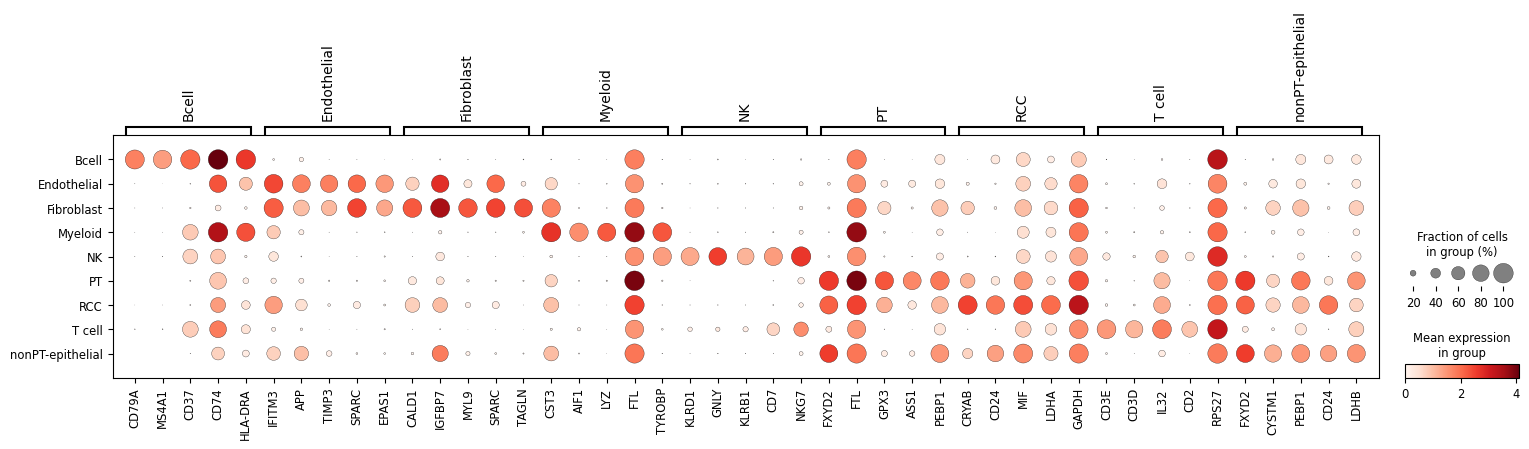

In [14]:
# Plot original DEGs on original adata
sc.pl.rank_genes_groups_dotplot(
    de_adata,
    key="rank_genes_groups",
    n_genes=5,
    groupby="broad_type", # Specify cluster grouping labels
    dendrogram=False,
    standard_scale=None,
    log=True,
    #save=""
)

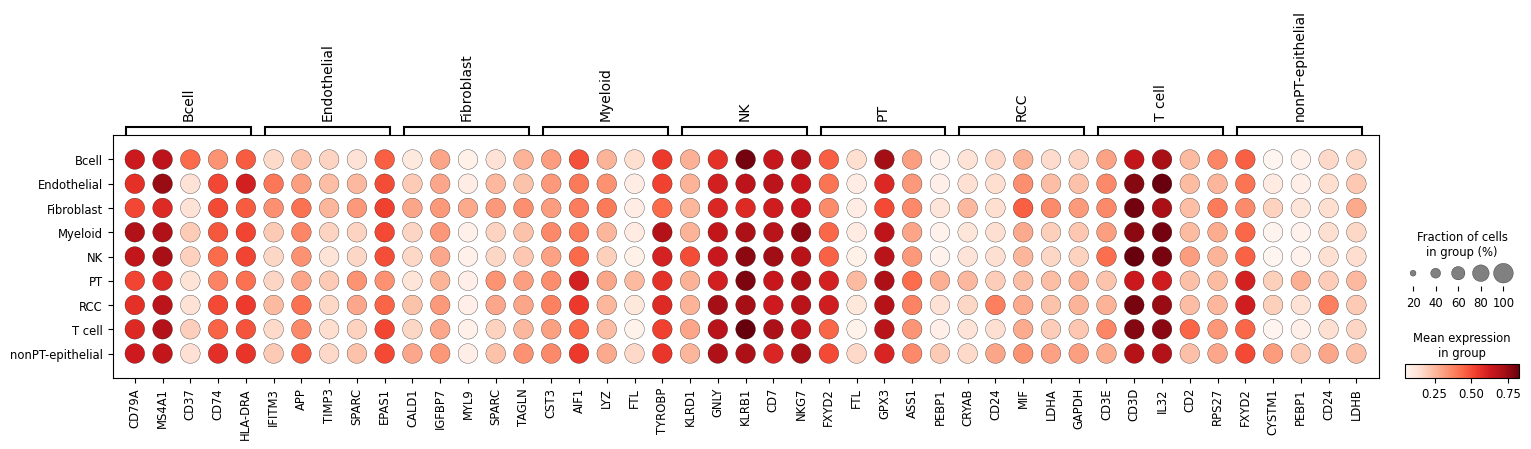

In [15]:
# Plot original DEGs on scNET-reconstructed adata
sc.pl.dotplot(
    adata_sc,
    var_names=original_top5_dict,
    groupby="broad_type", # Specify cluster grouping labels
    dendrogram=False,
    standard_scale=None,
    log=False, 
    #save=""
)

### 1.2 Visualisation via venn diagrams

In [98]:
# Match genes between all AnnData objects
print("Matching genes between AnnData objects...")
match_list = [adata, adata_y2h, adata_apms, adata_cpdb]

net_common_genes = match_list[0].var_names
for adata_obj in match_list[1:]:
    net_common_genes = net_common_genes.intersection(adata_obj.var_names)

print(f"Common genes across {len(match_list)} objects: {len(net_common_genes)}")

adata_net_gm = adata[:, net_common_genes].copy()

print("Preprocessing AnnData objects...")
adata_venn = adata_net_gm.copy() 
adata_venn.raw = adata_venn.copy() 
sc.pp.normalize_total(adata_venn, target_sum=1e4) 
sc.pp.log1p(adata_venn) 

adata_dict = {
    "Original": adata_venn,
    "Y2H": adata_y2h,
    "AP-MS": adata_apms,
    "CPDB": adata_cpdb,
}

deg_sets = {}
cluster_deg_sets_all = {}
all_counts = {}

print("Performing DGE analysis...")
for name, adata in adata_dict.items():

    prefix = name 
    
    deg_set, cluster_deg_sets, cluster_counts = get_cluster_deg_set(
        adata,
        groupby="broad_type",
        output_prefix=None,
        lfc_threshold=1.5,
        pval_threshold=0.05,
    )
    
    deg_sets[name] = deg_set
    cluster_deg_sets_all[name] = cluster_deg_sets
    all_counts[name] = cluster_counts
    
    print(f"{name}: {len(deg_sets[name])} DEGs")

Matching genes between AnnData objects...
Common genes across 4 objects: 5956
Preprocessing AnnData objects...
Performing DGE analysis...
Original: 2033 DEGs
Y2H: 493 DEGs
AP-MS: 744 DEGs
CPDB: 652 DEGs


In [112]:
print("Loading in table of DEGs per cluster across conditions...")
summary_df = pd.DataFrame(all_counts).fillna(0)
display(summary_df)

Loading in table of DEGs per cluster across conditions...


,Original,Y2H,AP-MS,CPDB
Bcell,116,26,23,37
Endothelial,651,134,214,204
Fibroblast,827,197,356,294
Myeloid,394,9,25,13
NK,85,0,1,0
PT,203,64,118,105
RCC,507,22,34,20
T cell,154,0,0,0
nonPT-epithelial,430,99,133,66


Removing overlapping DEGs with original...
Plotting venn diagram...


<Figure size 400x600 with 0 Axes>

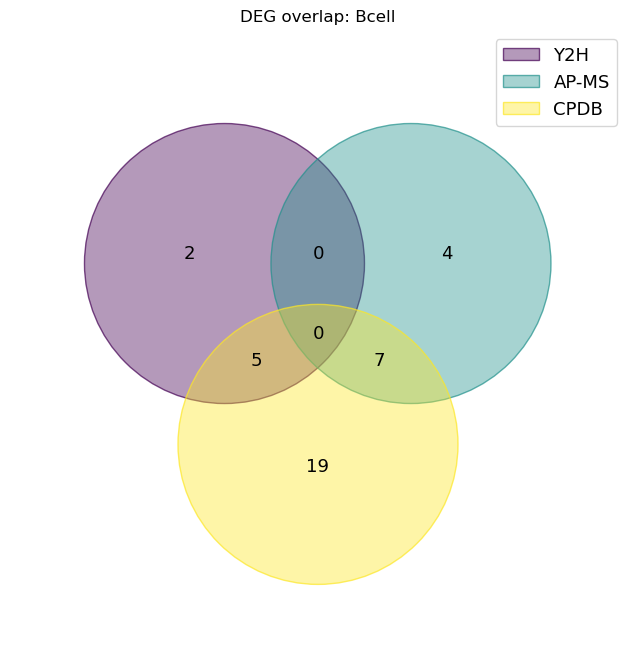

In [113]:
cluster_of_interest = "Bcell"

print("Removing overlapping DEGs with original...")

original_cluster_genes = cluster_deg_sets_all["Original"].get(cluster_of_interest, set())

filtered_cluster_deg_sets = {}

for dataset, cluster_dict in cluster_deg_sets_all.items():
    if dataset == "Original":
        continue
    
    filtered_cluster_deg_sets[dataset] = {}
    
    for clust, genes in cluster_dict.items():
        filtered_genes = set(genes) - original_cluster_genes
        filtered_cluster_deg_sets[dataset][clust] = filtered_genes
        
print("Plotting venn diagram...")

# Note: Replace 'filtered_cluster_deg_sets' with 'cluster_deg_sets_all' to get a 4-way venn diagram including the original
venn_dict = {
    name: genes
    for name, cluster_map in filtered_cluster_deg_sets.items() 
    if (genes := cluster_map.get(cluster_of_interest))
}

if len(venn_dict) < 2:
    raise ValueError("Need at least two datasets with genes for Venn diagram.")

plt.figure(figsize=(4,6))
venn(venn_dict)
plt.title(f"DEG overlap: {cluster_of_interest}")
plt.show()

## 2. UMAP clustering

Calculating and plotting UMAP...


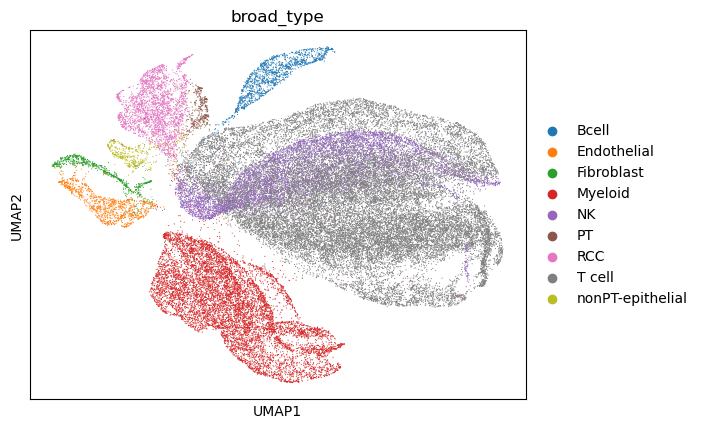

Calculating silhouette score...
broad_type: 9 clusters, 49428 cells
Silhouette score: 0.056


In [57]:
# =================================================================
# BY GENE EXPRESSION (PCA)
# =================================================================

# Define cluster column and file
cluster_col = "broad_type" # Specify cluster grouping labels
adata_umap = adata_sc.copy()
n_pc = 20
seed = 42

# Calculating UMAP with HVGs
print("Calculating and plotting UMAP...")
sc.pp.highly_variable_genes(adata_umap, n_top_genes=2000)
sc.tl.pca(adata_umap, random_state=seed)
sc.pp.neighbors(adata_umap, random_state=seed)
sc.tl.umap(adata_umap, random_state=seed)

sc.pl.umap(adata_umap, color=cluster_col, legend_loc='right margin')

# Calculate and display silhouette score
print("Calculating silhouette score...")
valid_mask = ~adata_umap.obs[cluster_col].isna()
n_clusters = adata_umap.obs[cluster_col][valid_mask].nunique()

print(f"{cluster_col}: {n_clusters} clusters, {valid_mask.sum()} cells")

if n_clusters >= 2:
    silhouette = silhouette_score(
        adata_umap.obsm['X_pca'][valid_mask, :n_pc],
        adata_umap.obs[cluster_col][valid_mask]
    )
    print(f"Silhouette score: {silhouette:.3f}")
else:
    print(f"Cannot calculate silhouette (only {n_clusters} cluster)")

Initial shape: (49428, 11802)

Loading embeddings from: /Users/cwen/Downloads/Data_files/scnet_results/RCC_subset_040326/RCC_subset_cell_embeddings.parquet
Embeddings shape: (49428, 75)
AnnData cells: 49428

Checking alignment...
  AnnData cells: 49428
  Embeddings cells: 49428
  AnnData unique: True
  Embeddings unique: True
 * Perfect match! Cells are in same order

Added embeddings to adata.obsm['X_scNET_embedding']
  Embedding dimensions: 75

Computing neighbors (n_neighbors=15, metric=euclidean)...
Computing UMAP...

broad_type: 9 clusters, 49428 cells
Silhouette score: 0.043

Generating UMAP plots...


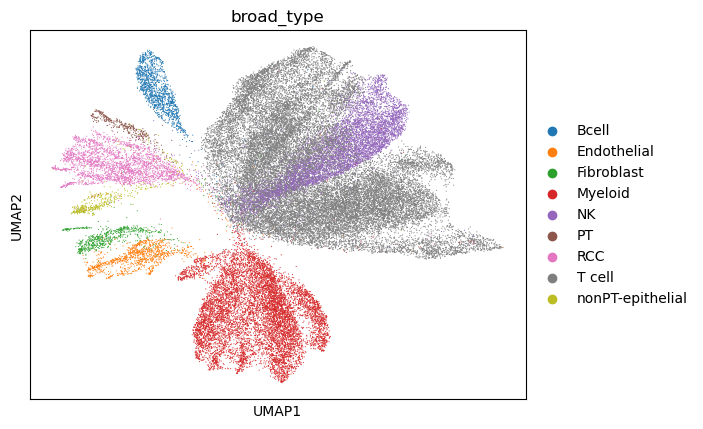


SUMMARY
Cells: 49428
Embedding dimensions: 75
Clusters: 9
Silhouette score: 0.043


In [88]:
# =================================================================
# BY CELL EMBEDDINGS
# =================================================================

results = process_with_embeddings(
    adata=adata_umap,
    embeddings_path=cell_embeddings_path,
    cluster_col="broad_type",  # Specify cluster grouping labels
    compute_leiden=False,  
    save_path=None,
    umap_save=None
)

## 3. Pathway enrichment

In [80]:
adata_ora = adata.copy() 

# Note: normalization and log1p transformation not needed for scNET-reconstructed objects
adata_ora.raw = adata_ora.copy()

sc.pp.normalize_total(adata_ora, target_sum=1e4)
sc.pp.log1p(adata_ora)

# Run differential rank 
print("Running differential expression analysis...")
sc.tl.rank_genes_groups(adata_ora, 
                        groupby="broad_type", # Specify cluster grouping labels
                        method="wilcoxon", 
                        key_added="rank_genes_groups",
                        use_raw=False # True for scNET-reconstructed objects
                       )
print("Done!")

Running differential expression analysis...
Done!


In [102]:
# ==========================================
# Run Pathway Enrichment for All Cell Types
# ==========================================

cell_types = adata_ora.obs["broad_type"].dropna().unique()
print(f"\nFound {len(cell_types)} cell types: {cell_types.tolist()}")

enrichment_results_dict = {}
significant_pathways_dict = {}

for cell_type in cell_types:

    full_results, significant = run_pathway_enrichment_for_cluster(
        adata_ora,
        cluster_name=cell_type,
        groupby="rank_genes_groups",
        gene_sets=None, # default: KEGG
        lfc_threshold=0,
        pval_threshold=0.05,
        output_dir=None 
    )

    if full_results is not None:
        enrichment_results_dict[cell_type] = full_results

    if significant is not None:
        significant_pathways_dict[cell_type] = significant


print(f"\nCompleted enrichment for {len(enrichment_results_dict)} cell types")


Found 9 cell types: ['T cell', 'Myeloid', 'Bcell', 'RCC', 'NK', 'Endothelial', 'PT', 'Fibroblast', 'nonPT-epithelial']

Processing cluster: T cell
  4003 significant genes
  Found 63 significant pathways

Processing cluster: Myeloid
  2805 significant genes
  Found 196 significant pathways

Processing cluster: Bcell
  902 significant genes
  Found 35 significant pathways

Processing cluster: RCC
  2292 significant genes
  Found 108 significant pathways

Processing cluster: NK
  1542 significant genes
  Found 100 significant pathways

Processing cluster: Endothelial
  3045 significant genes
  Found 167 significant pathways

Processing cluster: PT
  727 significant genes
  Found 64 significant pathways

Processing cluster: Fibroblast
  3943 significant genes
  Found 153 significant pathways

Processing cluster: nonPT-epithelial
  1543 significant genes
  Found 87 significant pathways

Completed enrichment for 9 cell types


Saving top pathways...
Total unique pathways selected: 51

Plotting heatmap...
Maximum -log10(adj_p): 70.49107394506231


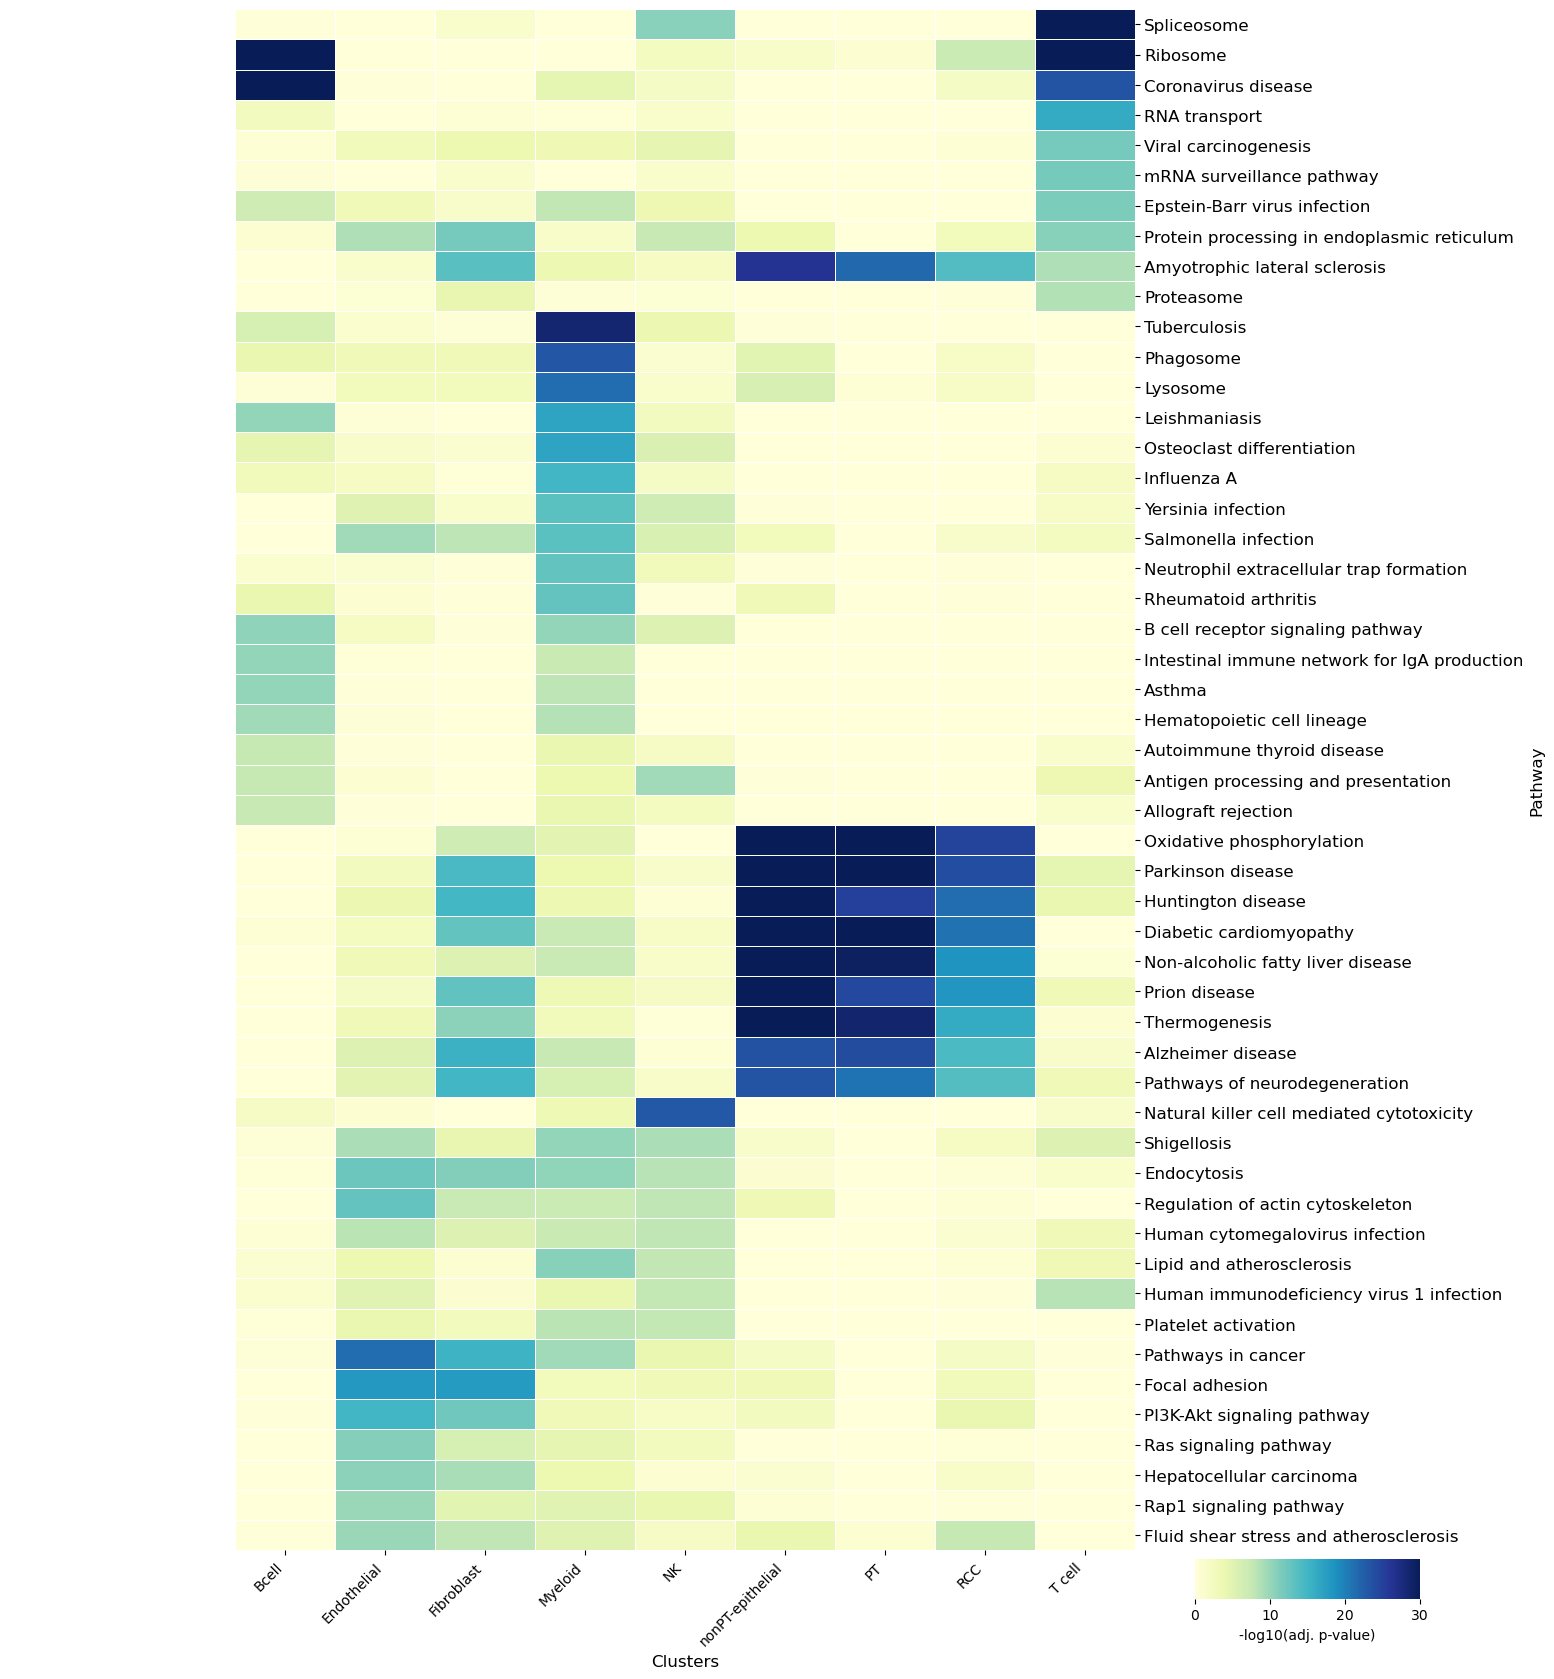

In [101]:
# Example: Plotting original top pathways against original data

cluster_order = ["Bcell", "Endothelial", "Fibroblast", "Myeloid", "NK", "nonPT-epithelial", "PT", "RCC", "T cell"]

print("Saving top pathways...")
original_top_pathways = []

for cluster, df in enrichment_results_dict.items():

    if df is None or df.empty:
        continue

    top_df = (
        df.sort_values("Adjusted P-value")
          .head(10)
    )

    for term in top_df["Term"]:
        if term not in original_top_pathways:
            original_top_pathways.append(term)

print(f"Total unique pathways selected: {len(original_top_pathways)}\n")

print("Plotting heatmap...")
plot_pathway_heatmap(enrichment_results_dict, top_n=None, pathway_list=original_top_pathways, 
                     cluster_order=cluster_order,
                     figsize=(15, 20), bar_pos=[0.8, 0.005, 0.15, 0.02], vmax_cap=30)

## 4. Rank-weight analysis

### 4.1 Mean expression levels

In [104]:
adata_immune = adata[adata.obs["broad_type"].isin(["T cell", "Myeloid", "NK", "Bcell"])].copy()
adata_immune_sc = adata_sc[adata_sc.obs["broad_type"].isin(["T cell", "Myeloid", "NK", "Bcell"])].copy()

In [105]:
# =================================================================
# GET MEAN EXPRESSION LEVELS 
# =================================================================

# 1. Get mean log expression 
mean_og_all = mean_log_expr(adata_immune, assume_log=True) ### CHANGE ACCORDINGLY ###
mean_sc_all = mean_log_expr(adata_immune_sc, assume_log=True) ### CHANGE ACCORDINGLY ###

# 2. Rank and top%/percentiles across entire gene set (not just shared genes between two datasets
rank_og_all = (mean_og_all.rank(method="first", ascending=False).astype(int))
rank_sc_all = (mean_sc_all.rank(method="first", ascending=False).astype(int))

top_pct_og_all = rank_og_all / len(rank_og_all) * 100
top_pct_sc_all = rank_sc_all / len(rank_sc_all) * 100

# Change to percentiles (percentage of genes with LOWER expression)
percentile_og_all = (len(rank_og_all) - rank_og_all + 1) / len(rank_og_all) * 100
percentile_sc_all = (len(rank_sc_all) - rank_sc_all + 1) / len(rank_sc_all) * 100

# 3. Get shared genes
shared_genes = mean_sc_all.index.intersection(mean_og_all.index)

mean_og_shared = mean_og_all.reindex(shared_genes)
mean_sc_shared = mean_sc_all.reindex(shared_genes)

assert mean_og_shared.shape == mean_sc_shared.shape
assert not np.allclose(mean_og_shared.values, mean_sc_shared.values)

print(f"Shared genes: {len(shared_genes)}")

# 4. Build comparison df
df = pd.DataFrame({
    "gene": shared_genes,
    "mean_log_expr_og": mean_og_all.loc[shared_genes],
    "mean_log_expr_sc": mean_sc_all.loc[shared_genes],
    "rank_og": rank_og_all.loc[shared_genes].values,
    "rank_sc": rank_sc_all.loc[shared_genes].values,
    "percentile_og": percentile_og_all.loc[shared_genes].values,
    "percentile_sc": percentile_sc_all.loc[shared_genes].values,
})

# Can adjust as needed
df["delta_percentile"] = (
    df["percentile_sc"] - df["percentile_og"]
)

df_sorted = (
    df.assign(abs_delta_percentile=lambda x: x["delta_percentile"].abs())
      .sort_values("abs_delta_percentile", ascending=False)
)

df_sorted.head(50)

Shared genes: 11683


,gene,mean_log_expr_og,mean_log_expr_sc,rank_og,rank_sc,percentile_og,percentile_sc,delta_percentile,abs_delta_percentile
ETNK2,ETNK2,0.784576,0.077140,612,11323,95.751339,4.067107,-91.684231,91.684231
MYCT1,MYCT1,0.720355,0.052229,1257,11645,91.266254,1.338756,-89.927498,89.927498
ARHGAP11A,ARHGAP11A,0.082507,0.792177,13809,734,3.984424,93.789188,89.804764,89.804764
ALG1,ALG1,0.127384,0.876595,13072,130,9.109241,98.906965,89.797724,89.797724
FRMD6,FRMD6,0.722883,0.064311,1232,11507,91.440095,2.508049,-88.932045,88.932045
SPTLC3,SPTLC3,0.770629,0.094331,746,11083,94.819554,6.100661,-88.718893,88.718893
NME5,NME5,0.837541,0.124332,229,10581,98.414575,10.354177,-88.060398,88.060398
ADGRA2,ADGRA2,0.705230,0.062910,1420,11526,90.132814,2.347060,-87.785754,87.785754
PNOC,PNOC,0.862925,0.131741,117,10435,99.193380,11.591256,-87.602124,87.602124
SLC15A3,SLC15A3,0.144221,0.862306,12682,195,11.821153,98.356211,86.535058,86.535058


In [152]:
# =================================================================
# OUTPUT
# =================================================================
output_dir = os.path.expanduser("~/Downloads/Data_files/Outputs")
os.makedirs(output_dir, exist_ok=True)

out_path = os.path.join(output_dir, "Example_adata_scNET_mean_expression_comparison.xlsx") 

df_sorted.to_excel(out_path, index=False)
print(f"Saved: {out_path}")

Saved: /Users/cwen/Downloads/Data_files/Outputs/Example_adata_scNET_mean_expression_comparison.xlsx


### 4.2 Obtain network and scNET-derived neighbors

In [139]:
# =================================================================
# OBTAINING NETWORK-DERIVED neighborS 
# =================================================================

# Specify network and source file
source = "ANAT3.0"
G_path = "~/Downloads/Data_files/format_h_sapiens.csv"

query_files = [
    "~/Downloads/Data_files/Outputs/adata_immune_prioritized_example.txt"
]

main(G_path, query_files, min_weight=0.5, top_k=None)

Loading network...
  - Found 1 invalid nodes, removing examples: ['-1']

Network loaded with 19,042 nodes and 545,436 edges.

Processing 21 query genes for adata_immune_prioritized_example

Found 13415 neighbors from 21 genes:


,query_gene,neighbor,rank,weight,degree
0,CD1D,B2M,1,0.915057,direct
1,CD1D,HLA-B,2,0.915057,second-degree
2,CD1D,HLA-C,3,0.915057,second-degree
3,CD1D,HLA-A,4,0.914975,second-degree
4,CD1D,HLA-G,5,0.914733,second-degree


Saved neighbor table: /Users/cwen/Downloads/Data_files/Outputs/ANAT3.0_adata_immune_prioritized_example_neighbors.csv
Saved neighbor counts: /Users/cwen/Downloads/Data_files/Outputs/summary_ANAT3.0_adata_immune_prioritized_example_neighbors.csv


All query files processed


In [141]:
# =================================================================
# OBTAINING scNET-DERIVED neighborS 
# =================================================================

results = get_scnet_neighbors(
    gene_embeddings_path=gene_embeddings_path,
    pos_sample_path="~/Downloads/Data_files/Outputs/adata_immune_prioritized_example.txt",
    pos_file_name="scNET_adata_immune_prioritized_example_neighbors.csv",
    sim_threshold=0,
    case="as_is"
)

Saved: /Users/cwen/Downloads/Data_files/Outputs/scNET_adata_immune_prioritized_example_neighbors.csv
Saved: /Users/cwen/Downloads/Data_files/Outputs/summary_scNET_adata_immune_prioritized_example_neighbors.csv



### 4.3 Weight normalization, comparison, and obtaining Gephi files

In [144]:
# =================================================================
# WEIGHT normalizATION 
# =================================================================

# Note: normalization should be done across all samples per method
# (e.g. all neighbors from the same scNET model)
files = [
    "/Users/cwen/Downloads/Data_files/Outputs/scNET_adata_immune_prioritized_example_neighbors.csv",

] 
column_name = "weight" # e.g. cosine_similarity, weight

print("Normalizing values...")
# Expand paths
files = [os.path.expanduser(f) for f in files]

# Load all data
dfs = [pd.read_csv(f) for f in files]

# Concatenate for global scaling
all_df = pd.concat(dfs, ignore_index=True)

# Min–max scaling across EVERYTHING
scaler = MinMaxScaler()
all_df[column_name] = scaler.fit_transform(all_df[[column_name]])

# Split back and save
start = 0
for df, path in zip(dfs, files):
    n = len(df)
    df_norm = all_df.iloc[start:start+n].copy()
    start += n

    output_path = path.replace(".csv", "_normalized.csv")
    df_norm.to_csv(output_path, index=False)

    print(f"Saved: {output_path}")

Normalizing values...
Saved: /Users/cwen/Downloads/Data_files/Outputs/scNET_adata_immune_prioritized_example_neighbors_normalized.csv


In [149]:
# =================================================================
# Comparing neighbors from input network vs. scNET 
# =================================================================

output_dir = os.path.expanduser("~/Downloads/Data_files/Outputs")
os.makedirs(output_dir, exist_ok=True)

top_k = [None]   # 10, 20, 50, 100, 200, or None

scnet_files = {
    f"{condition}": f"~/Downloads/Data_files/Outputs/scNET_adata_immune_prioritized_example_neighbors_normalized.csv",
} 

ppi_files = {
    f"{condition}": f"~/Downloads/Data_files/Outputs/ANAT3.0_adata_immune_prioritized_example_neighbors_normalized.csv",
}

for condition in [f"{condition}"]: 
    for k in top_k:
        df_analysis, df_overlap, df_gained, df_lost = neighbor_comparison_analysis(
            scnet_files[condition],
            ppi_files[condition],
            condition=condition,
            top_k=k,
            defined_PPI=defined_PPI,
            output_dir=output_dir,
            overlap=True, 
            gained_and_lost=False
        )

Saved:
  /Users/cwen/Downloads/Data_files/Outputs/scNET_ANAT3.0_adata_immune_all_comparison.csv
  /Users/cwen/Downloads/Data_files/Outputs/scNET_ANAT3.0_adata_immune_all_overlapping_neighbors.csv


In [155]:
# =================================================================
# Output overlapping neighbors as .gexf file for Gephi analysis
# =================================================================
"""
Generates a network file (.gexf) containing only overlapping edges between scNET and PPI for visualization in Gephi.

Output:
    Nodes: "query" genes and their overlapping "neighbor" genes
        Node attributes:
            - node_type ("query" or "neighbor")
            - weight_shift (edge-derived shift for neighbors)
            - delta_percentile (external node-level metric)

    Edges (undirected): Represent shared (overlapping) interactions
        Edge attributes:
            - weight_shift (signed difference: scNET − PPI, for color)
            - abs_weight_shift (magnitude of shift, for edge thickness)
            - scnet_weight (edge weight in scNET)
            - ppi_weight (edge weight in PPI)
            - ppi_degree (degree of interaction in PPI)
            
The resulting .gexf file can be loaded into Gephi for network visualization, 
where edge color reflects direction of change and edge thickness reflects magnitude of rewiring.
"""

print("Loading in mean expression levels for data extraction...")
df_delta = pd.read_excel("/Users/cwen/Downloads/Data_files/Outputs/Example_adata_scNET_mean_expression_comparison.xlsx")

df_delta["gene"] = df_delta["gene"].str.upper()

delta_map = dict(zip(df_delta["gene"], df_delta["delta_percentile"]))

print("Setting node and edge attributes...")
# Undirected PPI network
G = nx.Graph()

# Precompute absolute shift for edge thickness
df_overlap["abs_weight_shift"] = df_overlap["weight_shift"].abs()

# Dictionary to store node-level shift (for neighbours)
node_shift = {}
node_type = {}

for _, row in df_overlap.iterrows():
    query = row["query_gene"]
    neighbor = row["neighbor"]

    # ---- add edge with attributes ----
    G.add_edge(
        query,
        neighbor,
        weight_shift=row["weight_shift"],         # signed (for color)
        abs_weight_shift=row["abs_weight_shift"], # positive (for size)
        scnet_weight=row["weight_scnet"],
        ppi_weight=row["weight_ppi"],
        ppi_degree=row["ppi_degree"],
    )

    # ---- node attributes ----
    node_type[query] = "query"  # always query

    # only assign neighbor if not already a query
    if neighbor not in node_type:
        node_type[neighbor] = "neighbor"
    
    # ---- store node attribute for neighbour ----
    node_shift[neighbor] = row["weight_shift"]

# Apply node attributes
nx.set_node_attributes(G, node_type, name="node_type")
nx.set_node_attributes(G, node_shift, name="weight_shift")
nx.set_node_attributes(G, delta_map, name="delta_percentile")

# IMPORTANT: do NOT include `weight=`
# This prevents Gephi layouts from using signed weights
nx.write_gexf(
    G,
    f"scNET_ANAT3_{condition}_overlap_network.gexf"
) 

print("Done!")

Loading in mean expression levels for data extraction...
Setting node and edge attributes...
Done!
